## Testing

In [31]:
from pytweezer.experiment.motmaster_client import MotMasterClient
from pytweezer.drivers.imagemX2 import ImagEMX2Camera
from pytweezer.communication import SLMClient

from pytweezer import phasemask as pm
from pytweezer.analysis import analysis as pyt

import numpy as np

In [19]:
exp = MotMasterClient("Rb")

In [20]:
exp.set_save_toggle(False)
exp.set_iterations(10)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_iterations',
 'state': 'accepted'}

In [16]:
slm = SLMClient()

---

In [17]:
local_cam : ImagEMX2Camera = ImagEMX2Camera()

In [18]:
local_cam.set_trigger_source("ext")
local_cam.set_external_exposure_mode()
local_cam.enable_em_gain(True)
local_cam.enable_direct_em_gain(True)
local_cam.set_sensitivity(1200)
local_cam.timeout = 60*20
X0, Y0, WIDTH, HEIGHT = 50, 100, 384, 384
local_cam.set_roi(X0, WIDTH, Y0, HEIGHT)

---

In [42]:
dx, dy = 6.0, 0.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (46.0, -8.0) um


In [43]:
gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

In [44]:
W1 = np.ones((15, 15))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 15x15
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 2.94e-06 | Uniformity: 47.90% | Min/Max ratio: 0.030
Iteration 010 | Mean-Squared Error: 1.96e-08 | Uniformity: 79.29% | Min/Max ratio: 0.411
Iteration 020 | Mean-Squared Error: 1.09e-08 | Uniformity: 79.15% | Min/Max ratio: 0.417
Iteration 030 | Mean-Squared Error: 2.07e-09 | Uniformity: 78.82% | Min/Max ratio: 0.417
Iteration 040 | Mean-Squared Error: 9.30e-10 | Uniformity: 78.90% | Min/Max ratio: 0.430
Iteration 050 | Mean-Squared Error: 6.17e-10 | Uniformity: 78.94% | Min/Max ratio: 0.435
Iteration 060 | Mean-Squared Error: 3.10e-10 | Uniformity: 78.92% | Min/Max ratio: 0.434
Iteration 070 | Mean-Squared Error: 2.68e-10 | Uniformity: 78.92% | Min/Max ratio: 0.434
Iteration 080 | Mean-Squared Error: 2.27e-10 | Uniformity: 78.92% | Min/Max ratio: 0.434
Iteration 090 | Mean-Squared Error: 1.47e-10 | Uniformity: 78.92% | Min/Max ratio: 0.434
Itera

In [26]:
pm_composite = PM.superimpose([pm_array1, PM.fresnel, PM.blaze, PM.zernike])
pm_composite_uint8 = PM.transform_phase_8bit(pm_composite).get()
slm.update_mask(pm_composite_uint8)

{'status': 'success', 'msg': 'Mask updated successfully.'}

---
## Baseline Scan

In [33]:
texp = pyt.TweezerExperimentAnalysis(day='26',month='05May', year='2026')

---- 26/05May/202026 Tweezer Experiment Analysis Initialised ----


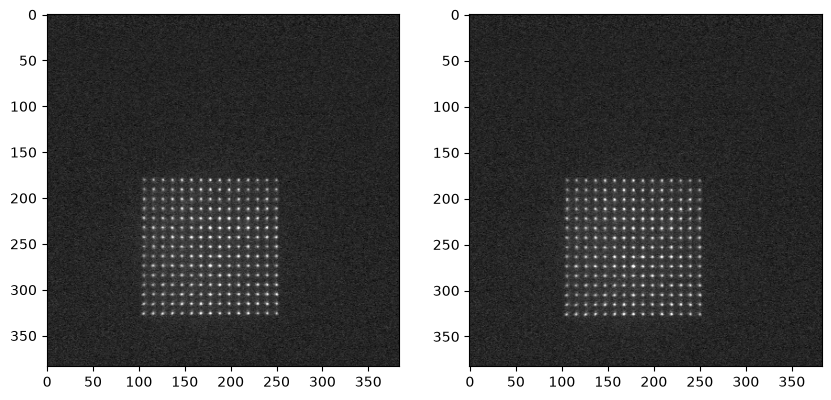

In [45]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
local_cam.setup_acquisition("snap", n_iterations * 2)
local_cam.start_acquisition()
exp.start_motmaster_experiment()

imgs = local_cam.acquire_n_frames(n_iterations * 2)
imgs1 = imgs[::2]
imgs2 = imgs[1::2]
img_average = texp.tweezer_show_bg_subtracted(imgs1, imgs2, reg=[0, -1, 0, -1], cmap='gray', show=True, vmaxfactor=0.6, show_grid=True)

Looking for trap sites...
15x15 array detected.


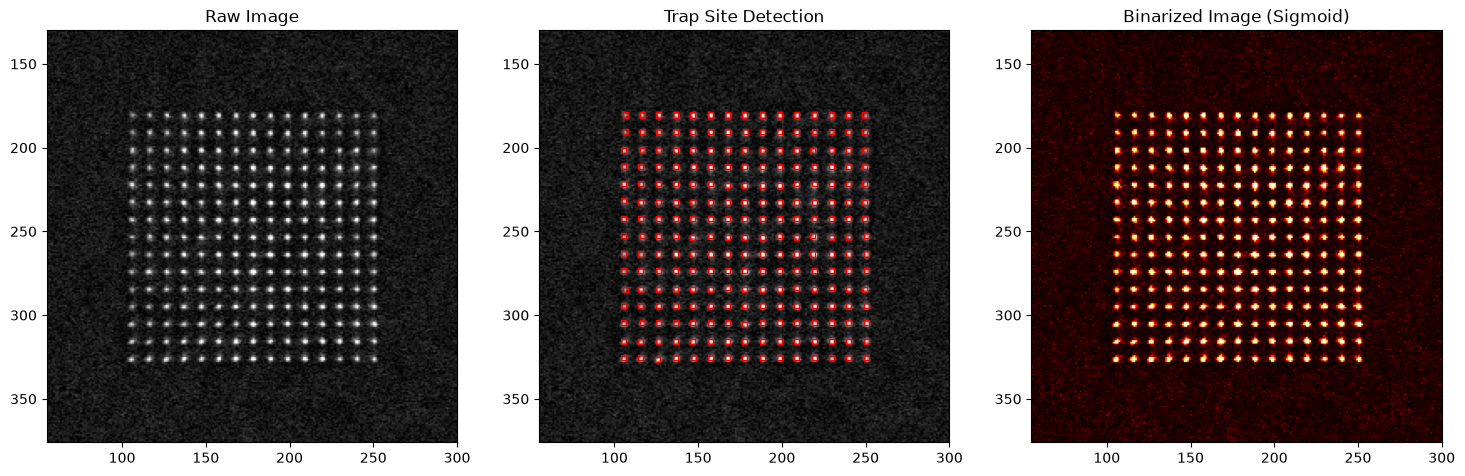

Trap (0, 0) Loading Probability : 47.00 %
Trap (0, 1) Loading Probability : 54.00 %
Trap (0, 2) Loading Probability : 54.00 %
Trap (0, 3) Loading Probability : 56.00 %
Trap (0, 4) Loading Probability : 58.00 %
Trap (0, 5) Loading Probability : 58.00 %
Trap (0, 6) Loading Probability : 48.00 %
Trap (0, 7) Loading Probability : 48.00 %
Trap (0, 8) Loading Probability : 56.00 %
Trap (0, 9) Loading Probability : 51.00 %
Trap (0, 10) Loading Probability : 63.00 %
Trap (0, 11) Loading Probability : 58.00 %
Trap (0, 12) Loading Probability : 48.00 %
Trap (0, 13) Loading Probability : 53.00 %
Trap (0, 14) Loading Probability : 37.00 %
Trap (1, 0) Loading Probability : 53.00 %
Trap (1, 1) Loading Probability : 51.00 %
Trap (1, 2) Loading Probability : 49.00 %
Trap (1, 3) Loading Probability : 46.00 %
Trap (1, 4) Loading Probability : 62.00 %
Trap (1, 5) Loading Probability : 50.00 %
Trap (1, 6) Loading Probability : 54.00 %
Trap (1, 7) Loading Probability : 55.00 %
Trap (1, 8) Loading Probabili

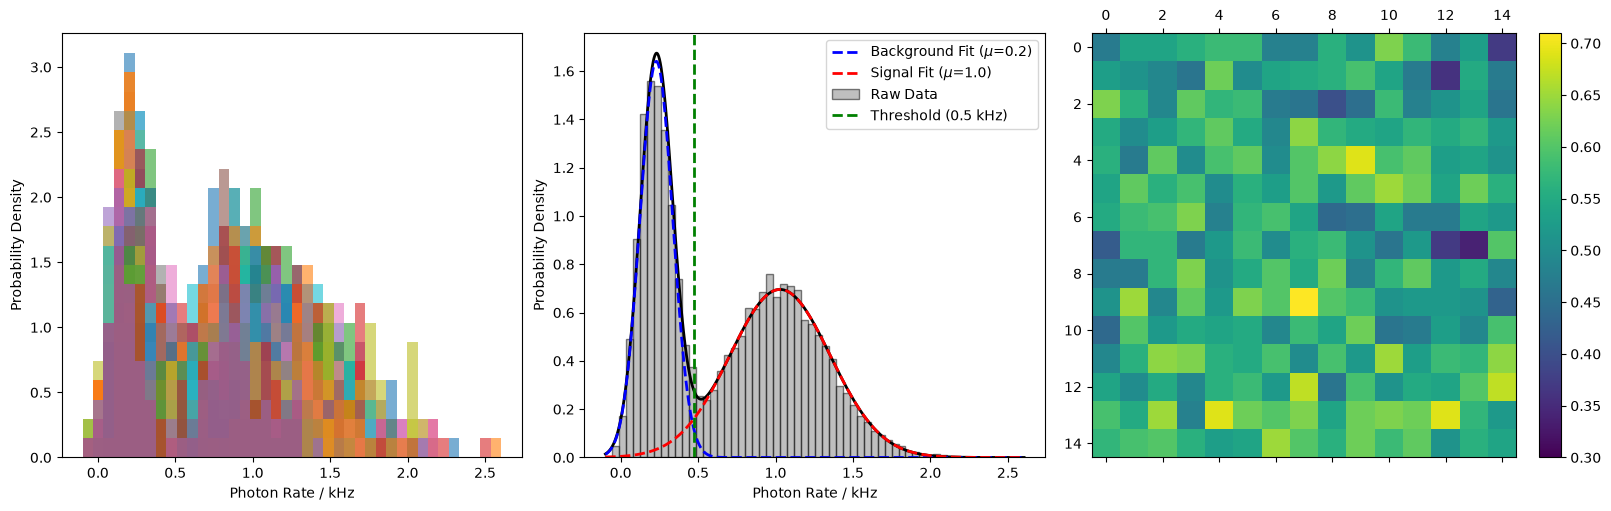

In [46]:
array_shape = [15, 15]
window = 3
feature_size = 10

filtered_img_average = pyt.morphological_tophat_high_pass(img_average, feature_size=feature_size)
grid_positions, detection_threshold = pyt.detect_trap_sites(filtered_img_average, array_shape, detection_step=100)
pyt.visualize_results(filtered_img_average, grid_positions, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [pyt.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates, loading_probabilities, threshold, fidelity = texp.get_array_loading_statistics(imgs_filtered, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60)